# α + $^{208}$Pb optical-model example

This notebook walks through the single-channel optical-model benchmark from Descouvemont's CPC paper.

We will:

1. define the optical Woods-Saxon + Coulomb potential,
2. visualize its real, imaginary, and Coulomb pieces,
3. evaluate the collision-matrix element for the benchmark energies,
4. compare all three validated solver paths:
   - real spectrum path (`eigh`)
   - complex spectrum path (`eig`)
   - complex direct path (`linear_solve` / `rmatrix_direct`)
5. compare the complex results against Descouvemont Appendix A.


In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm
from lax.boundary import BoundaryValues

OPTICAL_ENERGIES = np.array([10.0, 20.0, 30.0, 40.0, 50.0], dtype=np.float64)
APPENDIX_A_S = np.array(
    [
        1.0000e00 + 5.9801e-19j,
        1.0000e00 + 7.4950e-07j,
        9.9893e-01 + 9.0496e-03j,
        6.5081e-01 + 2.9560e-01j,
        6.4367e-02 + 4.1130e-02j,
    ],
    dtype=np.complex128,
)
ALPHA_PB_MASS_FACTOR = lm.constants.hbar2_over_2mu(
    4.001506, 207.9767
)  # α + ²⁰⁸Pb  MeV·fm²
BENCHMARK_L = 20
CHANNEL_RADIUS = 14.0


def optical_potential_parts(
    r: jnp.ndarray, imag_depth: float
) -> tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    v0 = 100.0
    radius = 1.1132 * (208.0 ** (1.0 / 3.0) + 4.0 ** (1.0 / 3.0))
    diffuseness = 0.5803
    woods_saxon = 1.0 / (1.0 + jnp.exp((r - radius) / diffuseness))
    nuclear_real = -v0 * woods_saxon
    nuclear_imag = -imag_depth * woods_saxon
    coulomb = 2.0 * 82.0 * 1.44 / r
    total = nuclear_real + coulomb + 1.0j * nuclear_imag
    return total, nuclear_real, nuclear_imag, coulomb


def optical_potential(r: jnp.ndarray, imag_depth: float) -> jnp.ndarray:
    total, _, _, _ = optical_potential_parts(r, imag_depth)
    return total


def complex_solver(method: str, solvers: tuple[str, ...]) -> lm.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("legendre", "x", n=60, scale=CHANNEL_RADIUS),
        channels=(
            lm.ChannelSpec(
                l=BENCHMARK_L, threshold=0.0, mass_factor=ALPHA_PB_MASS_FACTOR
            ),
        ),
        operators=("T+L",),
        solvers=solvers,
        energies=OPTICAL_ENERGIES,
        V_is_complex=True,
        method=method,
        z1z2=(2, 82),
    )


def real_solver(method: str, solvers: tuple[str, ...]) -> lm.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("legendre", "x", n=60, scale=CHANNEL_RADIUS),
        channels=(
            lm.ChannelSpec(
                l=BENCHMARK_L, threshold=0.0, mass_factor=ALPHA_PB_MASS_FACTOR
            ),
        ),
        operators=("T+L",),
        solvers=solvers,
        energies=OPTICAL_ENERGIES,
        method=method,
        z1z2=(2, 82),
    )


def smatrix_from_direct_rmatrix(
    solver: lm.Solver, potential: jnp.ndarray
) -> np.ndarray:
    assert solver.rmatrix_direct is not None
    assert solver.boundary is not None
    r_values = solver.rmatrix_direct(potential)
    smatrices = []
    for energy_index in range(r_values.shape[0]):
        boundary = BoundaryValues(
            H_plus=solver.boundary.H_plus[energy_index],
            H_minus=solver.boundary.H_minus[energy_index],
            H_plus_p=solver.boundary.H_plus_p[energy_index],
            H_minus_p=solver.boundary.H_minus_p[energy_index],
            is_open=solver.boundary.is_open[energy_index],
            k=solver.boundary.k[energy_index],
        )
        smatrix = lm.spectral.smatrix_from_R(r_values[energy_index], boundary)
        smatrices.append(np.asarray(smatrix))
    return np.stack(smatrices)

## Potential shape

The benchmark potential combines a real Woods-Saxon attraction, an imaginary absorptive Woods-Saxon part, and a point-Coulomb term. The complex optical calculation uses an imaginary depth of 10 MeV.

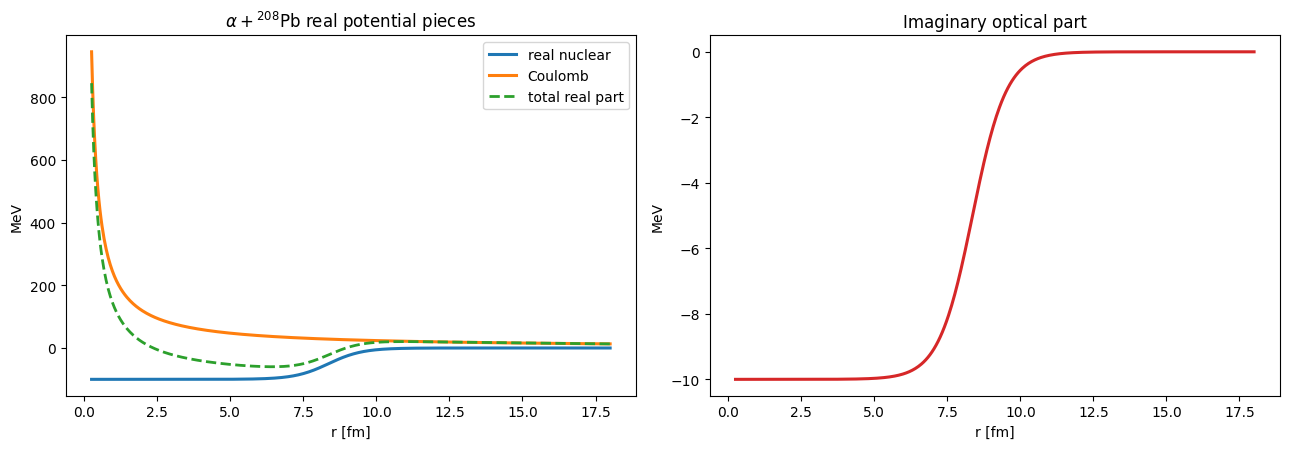

In [2]:
r_plot = np.linspace(0.25, 18.0, 500)
total, nuclear_real, nuclear_imag, coulomb = optical_potential_parts(
    jnp.asarray(r_plot), imag_depth=10.0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(r_plot, np.asarray(nuclear_real), label="real nuclear", linewidth=2.2)
axes[0].plot(r_plot, np.asarray(coulomb), label="Coulomb", linewidth=2.2)
axes[0].plot(
    r_plot, np.asarray(total.real), "--", label="total real part", linewidth=2.0
)
axes[0].set_title(r"$\alpha + {}^{208}\mathrm{Pb}$ real potential pieces")
axes[0].set_xlabel("r [fm]")
axes[0].set_ylabel("MeV")
axes[0].legend()

axes[1].plot(r_plot, np.asarray(nuclear_imag), color="tab:red", linewidth=2.2)
axes[1].set_title("Imaginary optical part")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("MeV")

fig.tight_layout()

## Three solver paths on the same benchmark

The validated test suite checks three related calculations:

- a **real-potential spectrum path** using `eigh`,
- a **complex spectrum path** using `eig`,
- a **complex direct path** using `linear_solve` and `rmatrix_direct`.

The complex `eig` and direct paths should both reproduce the published Appendix A collision-matrix values, and the real-potential `eigh` path provides a clean Hermitian reference limit.

In [ ]:
solver_real = real_solver("eigh", ("spectrum", "smatrix"))
solver_complex_eig = complex_solver("eig", ("spectrum", "smatrix"))
solver_complex_direct = complex_solver("linear_solve", ("rmatrix_direct",))

potential_real = solver_real.potential(
    lambda r: jnp.real(optical_potential(r, imag_depth=0.0))
)
potential_complex_eig = solver_complex_eig.potential(
    lambda r: optical_potential(r, imag_depth=10.0)
)
potential_complex_direct = solver_complex_direct.potential(
    lambda r: optical_potential(r, imag_depth=10.0)
)

smatrix_real = np.asarray(solver_real.smatrix(solver_real.spectrum(potential_real)))[
    :, 0, 0
]
smatrix_complex_eig = np.asarray(
    solver_complex_eig.smatrix(solver_complex_eig.spectrum(potential_complex_eig))
)[:, 0, 0]
smatrix_complex_direct = smatrix_from_direct_rmatrix(
    solver_complex_direct, potential_complex_direct
)[:, 0, 0]

print("Energy   Appendix A S(E)               eig S(E)                     direct S(E)")
for energy, appendix_value, eig_value, direct_value in zip(
    OPTICAL_ENERGIES,
    APPENDIX_A_S,
    smatrix_complex_eig,
    smatrix_complex_direct,
):
    print(
        f"{energy:5.1f}   {appendix_value.real: .6f}{appendix_value.imag:+.6f}j   "
        f"{eig_value.real: .6f}{eig_value.imag:+.6f}j   "
        f"{direct_value.real: .6f}{direct_value.imag:+.6f}j"
    )

print()
print(
    f"max |eig - Appendix A|    = {np.max(np.abs(smatrix_complex_eig - APPENDIX_A_S)):.3e}"
)
print(
    f"max |direct - Appendix A| = {np.max(np.abs(smatrix_complex_direct - APPENDIX_A_S)):.3e}"
)
print(
    f"max |eig - direct|        = {np.max(np.abs(smatrix_complex_eig - smatrix_complex_direct)):.3e}"
)

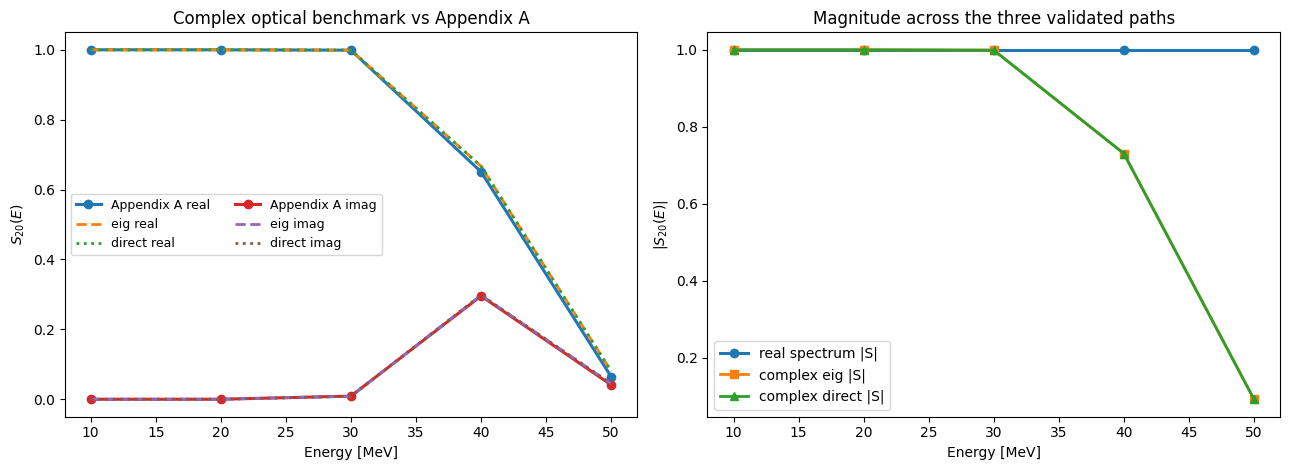

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    OPTICAL_ENERGIES, APPENDIX_A_S.real, "o-", label="Appendix A real", linewidth=2.2
)
axes[0].plot(
    OPTICAL_ENERGIES, smatrix_complex_eig.real, "--", label="eig real", linewidth=2.0
)
axes[0].plot(
    OPTICAL_ENERGIES,
    smatrix_complex_direct.real,
    ":",
    label="direct real",
    linewidth=2.0,
)
axes[0].plot(
    OPTICAL_ENERGIES, APPENDIX_A_S.imag, "o-", label="Appendix A imag", linewidth=2.2
)
axes[0].plot(
    OPTICAL_ENERGIES, smatrix_complex_eig.imag, "--", label="eig imag", linewidth=2.0
)
axes[0].plot(
    OPTICAL_ENERGIES,
    smatrix_complex_direct.imag,
    ":",
    label="direct imag",
    linewidth=2.0,
)
axes[0].set_title("Complex optical benchmark vs Appendix A")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel(r"$S_{20}(E)$")
axes[0].legend(ncol=2, fontsize=9)

axes[1].plot(
    OPTICAL_ENERGIES,
    np.abs(smatrix_real),
    marker="o",
    label="real spectrum |S|",
    linewidth=2.2,
)
axes[1].plot(
    OPTICAL_ENERGIES,
    np.abs(smatrix_complex_eig),
    marker="s",
    label="complex eig |S|",
    linewidth=2.0,
)
axes[1].plot(
    OPTICAL_ENERGIES,
    np.abs(smatrix_complex_direct),
    marker="^",
    label="complex direct |S|",
    linewidth=2.0,
)
axes[1].set_title("Magnitude across the three validated paths")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel(r"$|S_{20}(E)|$")
axes[1].legend()

fig.tight_layout()

The two complex methods track each other closely because they are evaluating the same physical optical-model problem through different numerical routes. The `eig` path uses the complex spectrum of the Bloch-augmented Hamiltonian, while the direct path evaluates the R-matrix with explicit linear solves at each energy. The real `eigh` path is included because it is the Hermitian limit of the same benchmark setup and provides a useful baseline for how the optical absorption changes the collision-matrix magnitude.

## Phase shifts across several partial waves

The single benchmark channel uses `l = 20`, but the same optical potential can be scanned across many partial waves. The expensive part here is the compile step, because it precomputes Coulomb boundary values across the full energy grid with `mpmath`. To make that cost visible, the scan is split into separate timed compile and solve cells.

These timed cells are tagged `skip-benchmark`, so they stay in the notebook for interactive use but are omitted from the automated notebook benchmark run.


In [5]:
%%time
fine_energies = jnp.linspace(14.0, 40.0, 60)
partial_waves = [0, 5, 10, 15, 20]
solvers = []
for angular_momentum in partial_waves:
    solvers.append(
        lm.compile(
            mesh=lm.MeshSpec("legendre", "x", n=60, scale=CHANNEL_RADIUS),
            channels=(
                lm.ChannelSpec(
                    l=angular_momentum, threshold=0.0, mass_factor=ALPHA_PB_MASS_FACTOR
                ),
            ),
            operators=("T+L",),
            solvers=("spectrum", "smatrix", "phases"),
            energies=fine_energies,
            V_is_complex=True,
            method="eig",
            z1z2=(2, 82),
        )
    )

CPU times: user 2min 44s, sys: 55.8 ms, total: 2min 44s
Wall time: 2min 44s


In [ ]:
%%time
phase_curves = {}
abs_s_curves = {}

for solver, angular_momentum in zip(solvers, partial_waves):
    potential = solver.potential(lambda r: optical_potential(r, imag_depth=10.0))
    spectrum = solver.spectrum(potential)
    phase_curves[angular_momentum] = np.asarray(solver.phases(spectrum)[:, 0]) * (
        180.0 / np.pi
    )
    abs_s_curves[angular_momentum] = np.abs(
        np.asarray(solver.smatrix(spectrum)[:, 0, 0])
    )

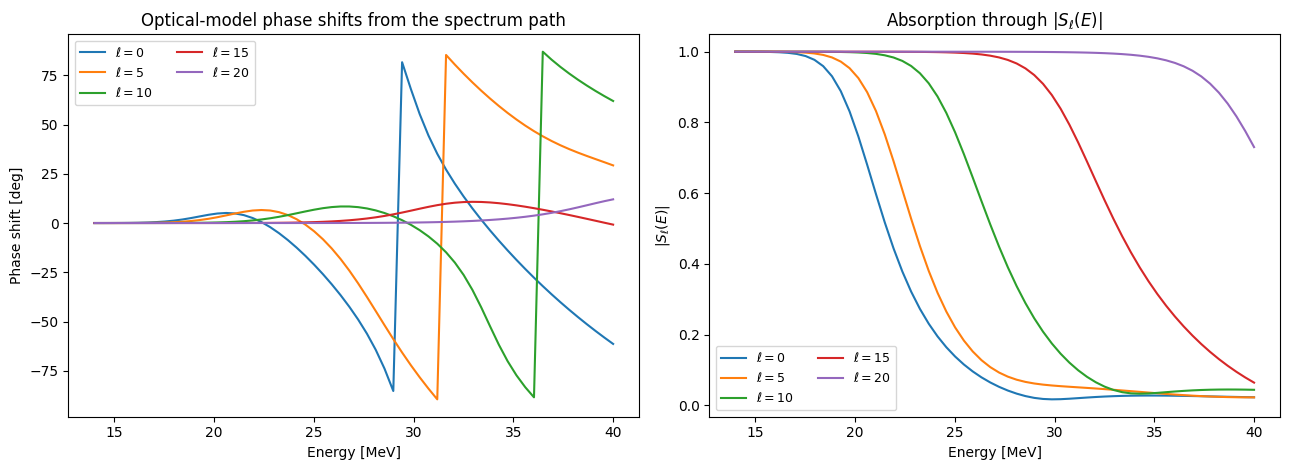

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for angular_momentum in partial_waves:
    axes[0].plot(
        np.asarray(fine_energies),
        phase_curves[angular_momentum],
        label=rf"$\ell={angular_momentum}$",
    )
    axes[1].plot(
        np.asarray(fine_energies),
        abs_s_curves[angular_momentum],
        label=rf"$\ell={angular_momentum}$",
    )

axes[0].set_title("Optical-model phase shifts from the spectrum path")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Phase shift [deg]")
axes[0].legend(ncol=2, fontsize=9)

axes[1].set_title(r"Absorption through $|S_\ell(E)|$")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel(r"$|S_\ell(E)|$")
axes[1].legend(ncol=2, fontsize=9)

fig.tight_layout()